In [34]:
import os
import json
import dill
import torch
import unicodedata
import numpy as np
import pandas as pd
from datasets import Dataset
from evaluate import load
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    BertTokenizerFast,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
    pipeline
)


In [35]:
with open("../data/frases_rotuladas.json", "r", encoding="utf-8") as f:
    data = json.load(f)
data[0]




{'text': 'no dia 12/06 acerto R$ 38',
 'id': 1,
 'entities': [{'start': 0,
   'end': 12,
   'text': 'no dia 12/06',
   'labels': ['TEMPO']},
  {'start': 13, 'end': 19, 'text': 'acerto', 'labels': ['PAGAMENTO']},
  {'start': 20, 'end': 25, 'text': 'R$ 38', 'labels': ['VALOR']}],
 'orientacao': [{'start': 0,
   'end': 12,
   'text': 'no dia 12/06',
   'labels': ['positiva']},
  {'start': 13, 'end': 19, 'text': 'acerto', 'labels': ['positiva']},
  {'start': 20, 'end': 25, 'text': 'R$ 38', 'labels': ['positiva']}],
 'modalidade': [{'start': 0,
   'end': 12,
   'text': 'no dia 12/06',
   'labels': ['planejado']},
  {'start': 13, 'end': 19, 'text': 'acerto', 'labels': ['afirmado']},
  {'start': 20, 'end': 25, 'text': 'R$ 38', 'labels': ['planejado']}],
 'referencia_temporal': [{'start': 0,
   'end': 12,
   'text': 'no dia 12/06',
   'labels': ['presente']},
  {'start': 13, 'end': 19, 'text': 'acerto', 'labels': ['presente']},
  {'start': 20, 'end': 25, 'text': 'R$ 38', 'labels': ['presente']

In [36]:
data[0]


{'text': 'no dia 12/06 acerto R$ 38',
 'id': 1,
 'entities': [{'start': 0,
   'end': 12,
   'text': 'no dia 12/06',
   'labels': ['TEMPO']},
  {'start': 13, 'end': 19, 'text': 'acerto', 'labels': ['PAGAMENTO']},
  {'start': 20, 'end': 25, 'text': 'R$ 38', 'labels': ['VALOR']}],
 'orientacao': [{'start': 0,
   'end': 12,
   'text': 'no dia 12/06',
   'labels': ['positiva']},
  {'start': 13, 'end': 19, 'text': 'acerto', 'labels': ['positiva']},
  {'start': 20, 'end': 25, 'text': 'R$ 38', 'labels': ['positiva']}],
 'modalidade': [{'start': 0,
   'end': 12,
   'text': 'no dia 12/06',
   'labels': ['planejado']},
  {'start': 13, 'end': 19, 'text': 'acerto', 'labels': ['afirmado']},
  {'start': 20, 'end': 25, 'text': 'R$ 38', 'labels': ['planejado']}],
 'referencia_temporal': [{'start': 0,
   'end': 12,
   'text': 'no dia 12/06',
   'labels': ['presente']},
  {'start': 13, 'end': 19, 'text': 'acerto', 'labels': ['presente']},
  {'start': 20, 'end': 25, 'text': 'R$ 38', 'labels': ['presente']

In [37]:
records = []
for item in data:
    try:
        for i, ent in enumerate(item["entities"]):
            records.append({
                "text":                        item["text"],
                "start":                       ent["start"],
                "end":                         ent["end"],
                "entity_label":                ent["labels"][0],
                "referencia_temporal_label":   item["referencia_temporal"][i]["labels"][0],
                "modalidade_label":            item["modalidade"][i]["labels"][0],
                "orientacao_label":            item["orientacao"][i]["labels"][0],
            })
    except Exception as e:
        print(f"Error: {e}, {item}")
len(records)


2183

In [38]:
records[0]


{'text': 'no dia 12/06 acerto R$ 38',
 'start': 0,
 'end': 12,
 'entity_label': 'TEMPO',
 'referencia_temporal_label': 'presente',
 'modalidade_label': 'planejado',
 'orientacao_label': 'positiva'}

In [39]:
df = pd.DataFrame(records)
df.head()


,text,start,end,entity_label,referencia_temporal_label,modalidade_label,orientacao_label
0,no dia 12/06 acerto R$ 38,0,12,TEMPO,presente,planejado,positiva
1,no dia 12/06 acerto R$ 38,13,19,PAGAMENTO,presente,afirmado,positiva
2,no dia 12/06 acerto R$ 38,20,25,VALOR,presente,planejado,positiva
3,"não vai dar pra agora, apenas quando resolver ...",0,15,CONDICAO,futuro,negado,negativa
4,"não vai dar pra agora, apenas quando resolver ...",30,59,CONDICAO,futuro,negado,negativa


In [40]:
def preprocessar_texto(texto):
    if not isinstance(texto, str):
        return texto
    texto = texto.lower()
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join([c for c in texto if not unicodedata.combining(c)])
    # texto = re.sub(r'[^\w\s]', ' ', texto)
    # texto = re.sub(r'\s+', ' ', texto).strip()
    
    return texto


In [41]:
df["text"] = df["text"].apply(preprocessar_texto)
df.head()


,text,start,end,entity_label,referencia_temporal_label,modalidade_label,orientacao_label
0,no dia 12/06 acerto r$ 38,0,12,TEMPO,presente,planejado,positiva
1,no dia 12/06 acerto r$ 38,13,19,PAGAMENTO,presente,afirmado,positiva
2,no dia 12/06 acerto r$ 38,20,25,VALOR,presente,planejado,positiva
3,"nao vai dar pra agora, apenas quando resolver ...",0,15,CONDICAO,futuro,negado,negativa
4,"nao vai dar pra agora, apenas quando resolver ...",30,59,CONDICAO,futuro,negado,negativa


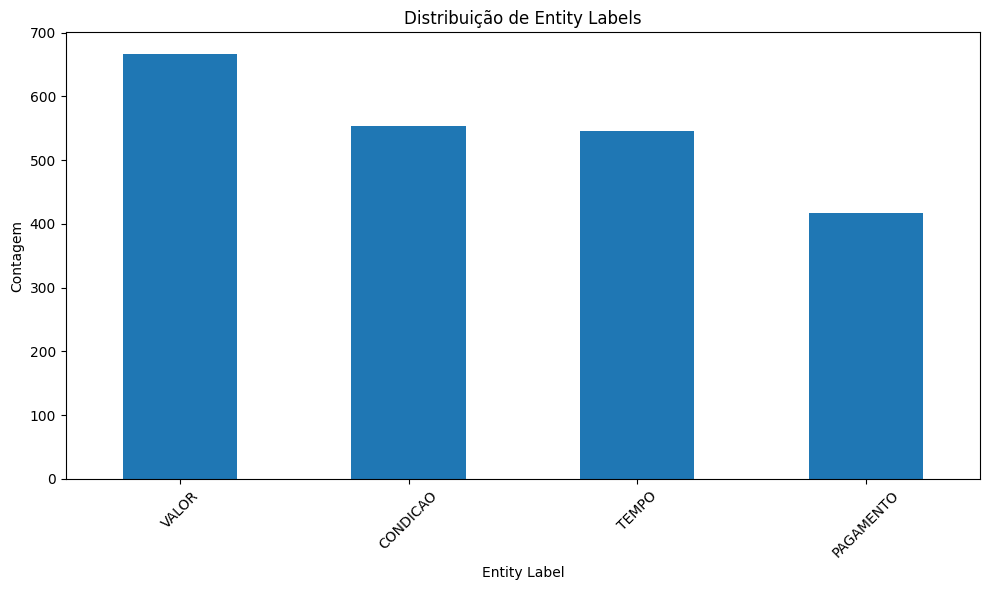

In [42]:
plt.figure(figsize=(10,6))
df['entity_label'].value_counts().plot(kind='bar')
plt.title('Distribuição de Entity Labels')
plt.xlabel('Entity Label')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [43]:
df_entity = df[['text', 'start', 'end', 'entity_label']]
df_entity.head()


,text,start,end,entity_label
0,no dia 12/06 acerto r$ 38,0,12,TEMPO
1,no dia 12/06 acerto r$ 38,13,19,PAGAMENTO
2,no dia 12/06 acerto r$ 38,20,25,VALOR
3,"nao vai dar pra agora, apenas quando resolver ...",0,15,CONDICAO
4,"nao vai dar pra agora, apenas quando resolver ...",30,59,CONDICAO


In [44]:
def to_iob_tags(group):
    text = group.name
    labels = ["O"] * len(text)
    for _, row in group.iterrows():
        for i in range(row.start, row.end):
            prefix = "B-" if i == row.start else "I-"
            labels[i] = prefix + row.entity_label
    return pd.DataFrame({"text": text, "tags": [labels]})


In [45]:
iob_df = (
    df_entity
    .groupby("text", sort=False)
    .apply(to_iob_tags)
    .reset_index(drop=True)
)
iob_df.head()


C:\Users\mathe\AppData\Local\Temp\ipykernel_30848\1260785468.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(to_iob_tags)


,text,tags
0,no dia 12/06 acerto r$ 38,"[B-TEMPO, I-TEMPO, I-TEMPO, I-TEMPO, I-TEMPO, ..."
1,"nao vai dar pra agora, apenas quando resolver ...","[B-CONDICAO, I-CONDICAO, I-CONDICAO, I-CONDICA..."
2,liso,"[B-CONDICAO, I-CONDICAO, I-CONDICAO, I-CONDICAO]"
3,parcelar 714 essa semana?,"[B-CONDICAO, I-CONDICAO, I-CONDICAO, I-CONDICA..."
4,to com 359 so,"[O, O, O, O, O, O, O, B-VALOR, I-VALOR, I-VALO..."


In [46]:
iob_df["words"] = iob_df["text"].str.split()

def chars_to_word_tags(text, char_tags):
    words = text.split()
    tags = []
    idx = 0
    for w in words:
        chunk = char_tags[idx : idx + len(w)]
        tag = next((t for t in chunk if t != "O"), "O")
        tags.append(tag)
        idx += len(w) + 1
    return tags

iob_df["word_tags"] = iob_df.apply(
    lambda row: chars_to_word_tags(row["text"], row["tags"]), axis=1
)


In [47]:
iob_df.head()


,text,tags,words,word_tags
0,no dia 12/06 acerto r$ 38,"[B-TEMPO, I-TEMPO, I-TEMPO, I-TEMPO, I-TEMPO, ...","[no, dia, 12/06, acerto, r$, 38]","[B-TEMPO, I-TEMPO, I-TEMPO, B-PAGAMENTO, B-VAL..."
1,"nao vai dar pra agora, apenas quando resolver ...","[B-CONDICAO, I-CONDICAO, I-CONDICAO, I-CONDICA...","[nao, vai, dar, pra, agora,, apenas, quando, r...","[B-CONDICAO, I-CONDICAO, I-CONDICAO, I-CONDICA..."
2,liso,"[B-CONDICAO, I-CONDICAO, I-CONDICAO, I-CONDICAO]",[liso],[B-CONDICAO]
3,parcelar 714 essa semana?,"[B-CONDICAO, I-CONDICAO, I-CONDICAO, I-CONDICA...","[parcelar, 714, essa, semana?]","[B-CONDICAO, B-VALOR, B-TEMPO, I-TEMPO]"
4,to com 359 so,"[O, O, O, O, O, O, O, B-VALOR, I-VALOR, I-VALO...","[to, com, 359, so]","[O, O, B-VALOR, O]"


In [48]:
iob_df.describe()


,text,tags,words,word_tags
count,895,895,895,895
unique,895,681,895,200
top,no dia 12/06 acerto r$ 38,"[B-VALOR, I-VALOR, I-VALOR, I-VALOR, I-VALOR, ...","[no, dia, 12/06, acerto, r$, 38]","[B-VALOR, I-VALOR, B-CONDICAO, I-CONDICAO, O, ..."
freq,1,7,1,36


In [49]:
letters = [x for x in iob_df.iloc[0].text]
labels  = [x for x in iob_df.iloc[0].tags]

for letter, label in zip(letters, labels):
    print(f"{letter} | {label}")


n | B-TEMPO
o | I-TEMPO
  | I-TEMPO
d | I-TEMPO
i | I-TEMPO
a | I-TEMPO
  | I-TEMPO
1 | I-TEMPO
2 | I-TEMPO
/ | I-TEMPO
0 | I-TEMPO
6 | I-TEMPO
  | O
a | B-PAGAMENTO
c | I-PAGAMENTO
e | I-PAGAMENTO
r | I-PAGAMENTO
t | I-PAGAMENTO
o | I-PAGAMENTO
  | O
r | B-VALOR
$ | I-VALOR
  | I-VALOR
3 | I-VALOR
8 | I-VALOR


In [50]:
iob_df = iob_df.drop(columns=["text", "tags"])


In [51]:
for i in range(10):
    letters = [x for x in iob_df.iloc[i].words]
    labels  = [x for x in iob_df.iloc[i].word_tags]

    for letter, label in zip(letters, labels):
        print(f"{letter:12} | {label}")
    print(f'{"="*30}')


no           | B-TEMPO
dia          | I-TEMPO
12/06        | I-TEMPO
acerto       | B-PAGAMENTO
r$           | B-VALOR
38           | I-VALOR
nao          | B-CONDICAO
vai          | I-CONDICAO
dar          | I-CONDICAO
pra          | I-CONDICAO
agora,       | O
apenas       | O
quando       | B-CONDICAO
resolver     | I-CONDICAO
uns          | I-CONDICAO
problemas    | I-CONDICAO
liso         | B-CONDICAO
parcelar     | B-CONDICAO
714          | B-VALOR
essa         | B-TEMPO
semana?      | I-TEMPO
to           | O
com          | O
359          | B-VALOR
so           | O
consegui     | O
juntar       | O
290          | B-VALOR
pra          | O
quitar       | B-PAGAMENTO
na           | B-TEMPO
proxima      | I-TEMPO
semana       | I-TEMPO
r$           | B-VALOR
1500         | I-VALOR
nao          | B-CONDICAO
consigo,     | I-CONDICAO
entao        | O
r$           | B-VALOR
200          | I-VALOR
acerto       | B-PAGAMENTO
semana       | B-TEMPO
que          | I-TEMPO
vem          | I-

In [52]:
train_df = iob_df.sample(frac=0.8, random_state=42)
eval_df  = iob_df.drop(train_df.index)

len(train_df),len(eval_df)


(716, 179)

In [53]:
train_ds = Dataset.from_pandas(train_df)
eval_ds  = Dataset.from_pandas(eval_df)

len(train_df),len(eval_df)


(716, 179)

In [54]:
checkpoint = "neuralmind/bert-base-portuguese-cased"
tokenizer = BertTokenizerFast.from_pretrained(checkpoint)


In [62]:
unique_tags = []
for tag_list in iob_df["word_tags"]:
    for tag in tag_list:
        if tag not in unique_tags:
            unique_tags.append(tag)
unique_tags


['B-TEMPO',
 'I-TEMPO',
 'B-PAGAMENTO',
 'B-VALOR',
 'I-VALOR',
 'B-CONDICAO',
 'I-CONDICAO',
 'O']

In [63]:
tag2id = {
    'O': 0,
    'B-TEMPO': 1,
    'I-TEMPO': 2,
    'B-PAGAMENTO': 3,
    'I-PAGAMENTO': 4,
    'B-VALOR': 5,
    'I-VALOR': 6,
    'B-CONDICAO': 7,
    'I-CONDICAO': 8,
}
id2tag = {idx: tag for tag, idx in tag2id.items()}

tag2id, id2tag


({'O': 0,
  'B-TEMPO': 1,
  'I-TEMPO': 2,
  'B-PAGAMENTO': 3,
  'I-PAGAMENTO': 4,
  'B-VALOR': 5,
  'I-VALOR': 6,
  'B-CONDICAO': 7,
  'I-CONDICAO': 8},
 {0: 'O',
  1: 'B-TEMPO',
  2: 'I-TEMPO',
  3: 'B-PAGAMENTO',
  4: 'I-PAGAMENTO',
  5: 'B-VALOR',
  6: 'I-VALOR',
  7: 'B-CONDICAO',
  8: 'I-CONDICAO'})

In [64]:
def encode_and_align_labels_word(examples):
    tokenized = tokenizer(
        examples["words"],
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=128,
    )
    all_labels = []
    for batch_idx in range(len(tokenized["input_ids"])):
        word_ids = tokenized.word_ids(batch_index=batch_idx)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            else:
                tag = examples["word_tags"][batch_idx][word_idx]
                # primeiro sub-token → mantém B-*, sub-tokens seguintes → converte B-* em I-*
                if word_idx != previous_word_idx:
                    label_id = tag2id[tag]
                else:
                    if tag.startswith("B-"):
                        tag = "I-" + tag.split("-", 1)[1]
                    label_id = tag2id[tag]
                label_ids.append(label_id)
            previous_word_idx = word_idx
        all_labels.append(label_ids)
    tokenized["labels"] = all_labels
    return tokenized


In [65]:
train_encodings = train_ds.map(
    encode_and_align_labels_word,
    batched=True,
    remove_columns=["words", "word_tags"]
)
eval_encodings = eval_ds.map(
    encode_and_align_labels_word,
    batched=True,
    remove_columns=["words", "word_tags"]
)

train_encodings.features


Map: 100%|██████████| 179/179 [00:00<00:00, 9882.72 examples/s]


{'__index_level_0__': Value(dtype='int64', id=None),
 'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None),
 'token_type_ids': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None),
 'attention_mask': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None),
 'labels': Sequence(feature=Value(dtype='int64', id=None), length=-1, id=None)}

In [66]:
frase = train_encodings[0]
for input_ids, labels, attention_mask in zip(frase['input_ids'], frase['labels'], frase['attention_mask']):
    if attention_mask == 1:
        print(f"input_ids: {input_ids:12} | label id: {labels:12} | equivalente: {id2tag[labels] if labels != -100 else '[PAD]':12} | attention_mask: {attention_mask:10}")



input_ids:          101 | label id:         -100 | equivalente: [PAD]        | attention_mask:          1
input_ids:         1104 | label id:            0 | equivalente: O            | attention_mask:          1
input_ids:        22283 | label id:            0 | equivalente: O            | attention_mask:          1
input_ids:         8488 | label id:            0 | equivalente: O            | attention_mask:          1
input_ids:         9945 | label id:            5 | equivalente: B-VALOR      | attention_mask:          1
input_ids:        22307 | label id:            6 | equivalente: I-VALOR      | attention_mask:          1
input_ids:         1174 | label id:            0 | equivalente: O            | attention_mask:          1
input_ids:        12174 | label id:            3 | equivalente: B-PAGAMENTO  | attention_mask:          1
input_ids:          931 | label id:            4 | equivalente: I-PAGAMENTO  | attention_mask:          1
input_ids:         3102 | label id:           

In [67]:
frase = train_encodings[0]
for input_ids, labels, attention_mask in zip(frase['input_ids'], frase['labels'], frase['attention_mask']):
    if attention_mask == 1:
        print(f"input_ids: {input_ids:12} | label id: {labels:12} | equivalente: {id2tag[labels] if labels != -100 else '[PAD]':12} | attention_mask: {attention_mask:10}")



input_ids:          101 | label id:         -100 | equivalente: [PAD]        | attention_mask:          1
input_ids:         1104 | label id:            0 | equivalente: O            | attention_mask:          1
input_ids:        22283 | label id:            0 | equivalente: O            | attention_mask:          1
input_ids:         8488 | label id:            0 | equivalente: O            | attention_mask:          1
input_ids:         9945 | label id:            5 | equivalente: B-VALOR      | attention_mask:          1
input_ids:        22307 | label id:            6 | equivalente: I-VALOR      | attention_mask:          1
input_ids:         1174 | label id:            0 | equivalente: O            | attention_mask:          1
input_ids:        12174 | label id:            3 | equivalente: B-PAGAMENTO  | attention_mask:          1
input_ids:          931 | label id:            4 | equivalente: I-PAGAMENTO  | attention_mask:          1
input_ids:         3102 | label id:           

In [68]:
exemplo = train_encodings[0]
tokens = tokenizer.convert_ids_to_tokens(exemplo['input_ids'])
labels = exemplo['labels']

print("Alinhamento token-label:")
print("-" * 30)
for token, label in zip(tokens, labels):
    if label != -100:
        print(f"{token:20} | {id2tag[label]}")

from collections import Counter
labels_validas = [l for l in labels if l != -100]
dist_labels = Counter(id2tag[l] for l in labels_validas)

print("\nDistribuição das labels:")
print("-" * 30)
for label, count in dist_labels.items():
    print(f"{label:20} | {count:}")


Alinhamento token-label:
------------------------------
consegu              | O
##i                  | O
juntar               | O
47                   | B-VALOR
##0                  | I-VALOR
pra                  | O
depos                | B-PAGAMENTO
##itar               | I-PAGAMENTO
neste                | B-TEMPO
momento              | I-TEMPO

Distribuição das labels:
------------------------------
O                    | 4
B-VALOR              | 1
I-VALOR              | 1
B-PAGAMENTO          | 1
I-PAGAMENTO          | 1
B-TEMPO              | 1
I-TEMPO              | 1


In [70]:
model = AutoModelForTokenClassification.from_pretrained(
    checkpoint,
    num_labels=len(id2tag.keys()),  
    id2label=id2tag,        
    label2id=tag2id    
)


Some weights of BertForTokenClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [71]:
data_collator = DataCollatorForTokenClassification(tokenizer)


In [72]:

training_args = TrainingArguments(
    output_dir="./bert-ner",
    do_train=True,
    do_eval=True,
    eval_strategy="epoch",   
    logging_strategy="steps",   
    save_strategy="steps",    
    eval_steps=200,             
    logging_steps=50,           
    save_steps=200,             
    per_device_train_batch_size=36,
    per_device_eval_batch_size=36,
    num_train_epochs=5,
    learning_rate=3e-5,
    weight_decay=0.01,
    no_cuda=False,
    use_cpu=False,
)


In [74]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_encodings,
    eval_dataset=eval_encodings,
    tokenizer=tokenizer,
    data_collator=data_collator,
)


C:\Users\mathe\AppData\Local\Temp\ipykernel_30848\2257340954.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [75]:
trainer.train()


Epoch,Training Loss,Validation Loss
1,No log,0.890549
2,No log,0.355373
3,0.942900,0.169878
4,0.942900,0.105922
5,0.124900,0.089708


TrainOutput(global_step=100, training_loss=0.533891224861145, metrics={'train_runtime': 37.1733, 'train_samples_per_second': 96.306, 'train_steps_per_second': 2.69, 'total_flos': 233875397514240.0, 'train_loss': 0.533891224861145, 'epoch': 5.0})

In [76]:
metrics = trainer.evaluate()
metrics



{'eval_loss': 0.08970759063959122,
 'eval_runtime': 0.493,
 'eval_samples_per_second': 363.08,
 'eval_steps_per_second': 10.142,
 'epoch': 5.0}

In [77]:
metric = load("seqeval")


In [78]:
def strip_prefix(tag):
    return tag if tag == "O" else tag.split("-", 1)[1]

def align_predictions(predictions, label_ids):
    preds = np.argmax(predictions, axis=2)
    batch_size, seq_len = preds.shape

    true_labels = []
    true_preds  = []
    for i in range(batch_size):
        curr_preds  = []
        curr_labels = []
        for j in range(seq_len):
            if label_ids[i, j] != -100:
                pred_tag = id2tag[preds[i, j]]
                true_tag = id2tag[label_ids[i, j]]
                curr_preds.append(strip_prefix(pred_tag))
                curr_labels.append(strip_prefix(true_tag))
        true_preds.append(curr_preds)
        true_labels.append(curr_labels)
    return true_preds, true_labels


In [79]:
predictions, label_ids, _ = trainer.predict(eval_encodings)



In [80]:
true_preds, true_labels = align_predictions(predictions, label_ids)


In [81]:
for i in range(5):
    print("SENTENÇA:", ' '.join(eval_ds[i]["words"]))
    print("Word         | True         | Pred")
    print("_"*40)
    for word, true, pred in zip(eval_ds[i]["words"], true_labels[i], true_preds[i]):
        print(f"{word}{(12-len(word))*' '} | {true}{(12-len(true))*' '} | {pred}")
    print(f'{"="*40}')
    print(f'')
    
    


SENTENÇA: nao vai dar pra agora, apenas quando resolver uns problemas
Word         | True         | Pred
________________________________________
nao          | CONDICAO     | CONDICAO
vai          | CONDICAO     | CONDICAO
dar          | CONDICAO     | CONDICAO
pra          | CONDICAO     | CONDICAO
agora,       | CONDICAO     | CONDICAO
apenas       | O            | O
quando       | O            | O
resolver     | O            | O
uns          | CONDICAO     | CONDICAO
problemas    | CONDICAO     | CONDICAO

SENTENÇA: to com 359 so
Word         | True         | Pred
________________________________________
to           | O            | O
com          | O            | O
359          | VALOR        | VALOR
so           | VALOR        | VALOR

SENTENÇA: sem grana
Word         | True         | Pred
________________________________________
sem          | CONDICAO     | CONDICAO
grana        | CONDICAO     | CONDICAO

SENTENÇA: 280 reais da pra fazer
Word         | True         | Pred
____

In [82]:
results = metric.compute(predictions=true_preds, references=true_labels)

print({k: v for k, v in results.items() if k.endswith("f1")})
print({k: v for k, v in results.items() if k.endswith("precision")})
print({k: v for k, v in results.items() if k.endswith("recall")})


{'overall_f1': 0.9464052287581698}
{'overall_precision': 0.9378238341968912}
{'overall_recall': 0.9551451187335093}


c:\Users\mathe\repos\study\POLI\NLP\t1\.venv\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: CONDICAO seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
c:\Users\mathe\repos\study\POLI\NLP\t1\.venv\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: VALOR seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
c:\Users\mathe\repos\study\POLI\NLP\t1\.venv\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: TEMPO seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
c:\Users\mathe\repos\study\POLI\NLP\t1\.venv\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: PAGAMENTO seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


In [83]:
ner = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)


Device set to use cuda:0


In [84]:
frase = "eu nao vou conseguir pagar esse mes, mas consigo pagar no proximo se tiver algum desconto"

result = ner(frase)
for ent in result:
    print(f"{ent['word']:30} → {ent['entity_group']:30} score: {ent['score']:.2f}") 


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


nao vou conseguir              → CONDICAO                       score: 0.93
pagar                          → PAGAMENTO                      score: 0.95
esse mes,                      → TEMPO                          score: 0.96
pagar                          → PAGAMENTO                      score: 0.97
no proximo                     → TEMPO                          score: 0.98
se tiver algum desconto        → CONDICAO                       score: 0.97


In [85]:
ds = Dataset.from_pandas(df)
ds[0]


{'text': 'no dia 12/06 acerto r$ 38',
 'start': 0,
 'end': 12,
 'entity_label': 'TEMPO',
 'referencia_temporal_label': 'presente',
 'modalidade_label': 'planejado',
 'orientacao_label': 'positiva'}

In [86]:
def encode_and_extract_spans(examples):
    tokenized = tokenizer(
        examples["text"],
        return_offsets_mapping=True,
        truncation=True,
        padding="max_length",
        max_length=128,
    )
    span_token_indices = []
    for i, offsets in enumerate(tokenized["offset_mapping"]):
        s, e = examples["start"][i], examples["end"][i]
        idxs = [j for j, (st, en) in enumerate(offsets) if not (en <= s or st >= e)]
        span_token_indices.append(idxs)
    tokenized["span_token_indices"] = span_token_indices
    tokenized.pop("offset_mapping")
    return tokenized

ds_enc = ds.map(encode_and_extract_spans, batched=True)


Map: 100%|██████████| 2183/2183 [00:00<00:00, 10451.96 examples/s]


In [87]:
ds_enc[0]['text']


'no dia 12/06 acerto r$ 38'

In [88]:
for input_ids, attention_mask in zip(ds_enc[0]['input_ids'], ds_enc[0]['attention_mask']):
    if attention_mask == 1:
        print(f"input_ids: {input_ids:10} |  attention_mask: {attention_mask:10}")


input_ids:        101 |  attention_mask:          1
input_ids:        202 |  attention_mask:          1
input_ids:        644 |  attention_mask:          1
input_ids:       1242 |  attention_mask:          1
input_ids:        120 |  attention_mask:          1
input_ids:      18838 |  attention_mask:          1
input_ids:       3813 |  attention_mask:          1
input_ids:        183 |  attention_mask:          1
input_ids:       1335 |  attention_mask:          1
input_ids:        109 |  attention_mask:          1
input_ids:       8103 |  attention_mask:          1
input_ids:        102 |  attention_mask:          1


In [89]:
ent_labels = ds_enc["entity_label"]

ohe = OneHotEncoder(sparse_output=False).fit(
    [[lbl] for lbl in ent_labels]
)

onehots = ohe.transform([[lbl] for lbl in ent_labels]).tolist()

ds_enc = ds_enc.add_column(
    "entity_onehot",
    onehots
)


In [90]:
print(ds_enc.column_names)
print(ds_enc[0]["entity_onehot"])


['text', 'start', 'end', 'entity_label', 'referencia_temporal_label', 'modalidade_label', 'orientacao_label', 'input_ids', 'token_type_ids', 'attention_mask', 'span_token_indices', 'entity_onehot']
[0.0, 0.0, 1.0, 0.0]


In [91]:
target_cols = [
    "referencia_temporal_label",
    "modalidade_label",
    "orientacao_label",
]
encoders = {}
for col in target_cols:
    le = LabelEncoder().fit(ds_enc[col])
    encoders[col] = le
    ds_enc = ds_enc.add_column(
        f"{col}_id",
        le.transform(ds_enc[col]).tolist()
    )


In [92]:
ds_enc.column_names, ds_enc[0]['orientacao_label_id']


(['text',
  'start',
  'end',
  'entity_label',
  'referencia_temporal_label',
  'modalidade_label',
  'orientacao_label',
  'input_ids',
  'token_type_ids',
  'attention_mask',
  'span_token_indices',
  'entity_onehot',
  'referencia_temporal_label_id',
  'modalidade_label_id',
  'orientacao_label_id'],
 1)

In [93]:
def extract_entity_features(bert_model, input_ids, attention_mask, span_indices, entity_onehot):
    device = next(bert_model.parameters()).device
    with torch.no_grad():
        outputs = bert_model(
            input_ids=torch.tensor(input_ids).unsqueeze(0).to(device),
            attention_mask=torch.tensor(attention_mask).unsqueeze(0).to(device),
            
        )
        hidden_states = outputs.last_hidden_state[0]  # [seq_len, 768]
    
    # 1. EMBEDDING DA FRASE TODA (token CLS)
    sentence_embedding = hidden_states[0]  # [768] - token [CLS]
    
    # 2. EMBEDDING DA ENTIDADE ESPECÍFICA  
    if len(span_indices) > 0:
        entity_embedding = hidden_states[span_indices].mean(dim=0)  # [768]
    else:
        entity_embedding = torch.zeros(768, device=device)
    
    # 3. CONTEXTO LOCAL (tokens ao redor da entidade)
    context_start = max(0, span_indices[0] - 2)
    context_end = min(len(hidden_states), span_indices[0] + 3)
    context_embedding = hidden_states[context_start:context_end].mean(dim=0)  # [768]
    
    # 4. TIPO DA ENTIDADE
    entity_type = torch.tensor(entity_onehot, dtype=torch.float32, device=device)  # [4]
    
    # 5. CONCATENAR TUDO
    features = torch.cat([
        sentence_embedding,   # 768 - contexto global
        entity_embedding,     # 768 - entidade específica  
        context_embedding,    # 768 - contexto local
        entity_type          # 4   - tipo da entidade
    ])  # Total: 768 + 768 + 768 + 4 = 2308 dimensões
    
    return features


In [94]:
features = extract_entity_features(
    model.bert,
    ds_enc[0]['input_ids'],
    ds_enc[0]['attention_mask'], 
    ds_enc[0]['span_token_indices'],
    ds_enc[0]['entity_onehot']
)
features.shape, features[:5]


(torch.Size([2308]),
 tensor([ 0.1475, -0.3710,  0.6439, -0.7778, -0.1763], device='cuda:0'))

In [95]:
def process_example(example):
    features = extract_entity_features(
        model.bert,
        example['input_ids'],
        example['attention_mask'], 
        example['span_token_indices'],
        example['entity_onehot']
    )
    
    return {
        'features': features.cpu().numpy(),
        'labels': [
            example['referencia_temporal_label_id'],
            example['modalidade_label_id'],
            example['orientacao_label_id']
        ]
    }


In [96]:
ds_features = ds_enc.map(process_example, desc="Extraindo features")


Extraindo features: 100%|██████████| 2183/2183 [00:25<00:00, 86.15 examples/s]


In [97]:
def expand_features_and_labels(example):
    feature_dict = {f'feature_{i}': example['features'][i] for i in range(len(example['features']))}
    
    label_dict = {
        'referencia_temporal': example['labels'][0],
        'modalidade': example['labels'][1], 
        'orientacao': example['labels'][2]
    }
    return {**feature_dict, **label_dict}


In [98]:
ds = ds_features.map(expand_features_and_labels)


Map: 100%|██████████| 2183/2183 [00:09<00:00, 233.25 examples/s]


In [99]:
len(ds.column_names)


2328

In [100]:
ds = ds.remove_columns(['text',
                        'start',
                        'end',
                        'entity_label',
                        'referencia_temporal_label',
                        'modalidade_label',
                        'orientacao_label',
                        'input_ids',
                        'token_type_ids',
                        'attention_mask',
                        'span_token_indices',
                        'entity_onehot',
                        'referencia_temporal_label_id',
                        'modalidade_label_id',
                        'orientacao_label_id',
                        'features',
                        'labels',])


In [101]:
len(ds.column_names)


2311

In [102]:
label_columns = ds.column_names[-3:]

X = ds.remove_columns(label_columns)
y = ds.select_columns(label_columns)

X.shape, y.shape


((2183, 2308), (2183, 3))

In [103]:
X_array = np.array(X.to_pandas())
y_array = np.array(y.to_pandas())

X_array[0][0]


0.14753814041614532

In [104]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_array)

pca = PCA(n_components=0.95, ) 
X_reduced = pca.fit_transform(X_scaled)

print(f"Dimensões originais: {X.shape[1]}") 
print(f"Dimensões reduzidas: {X_reduced.shape[1]}")
print(f"Variância explicada: {pca.explained_variance_ratio_.sum():.2f}")


Dimensões originais: 2308
Dimensões reduzidas: 145
Variância explicada: 0.95


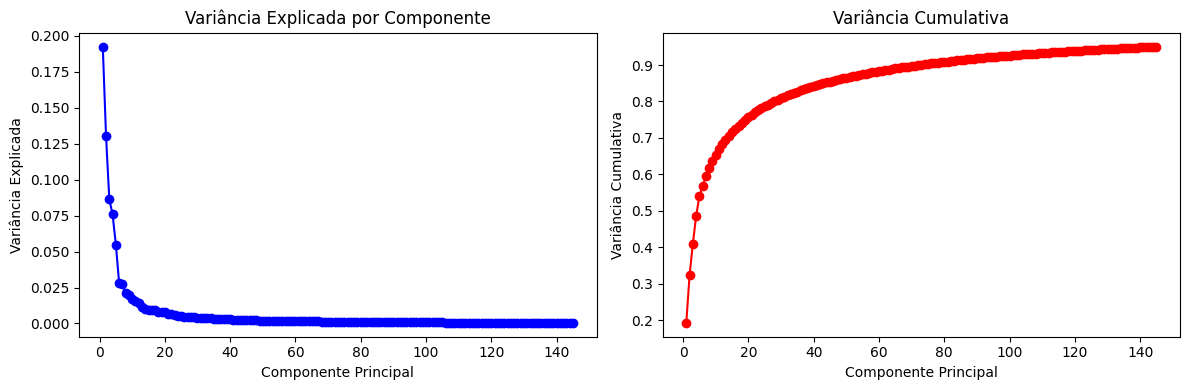

In [105]:

size = X_reduced.shape[1] 
# Explicação da variância por componente
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, size + 1), pca.explained_variance_ratio_[:size], 'bo-')
plt.title('Variância Explicada por Componente')
plt.xlabel('Componente Principal')
plt.ylabel('Variância Explicada')

plt.subplot(1, 2, 2)
plt.plot(range(1, size + 1), pca.explained_variance_ratio_[:size].cumsum(), 'ro-')
plt.title('Variância Cumulativa')
plt.xlabel('Componente Principal')
plt.ylabel('Variância Cumulativa')
plt.tight_layout()
plt.show()


In [106]:
X_reduced


array([[-24.8690978 ,  21.32662167,  -8.24031314, ...,   1.50536271,
          1.14064966,   0.26922644],
       [-11.73754992,  13.03616305,  21.49882199, ...,   1.05715902,
          0.56364481,   0.61914604],
       [ 17.93423407,  16.43167784,   4.66439481, ...,   1.27114238,
          0.14904409,   1.7417136 ],
       ...,
       [ -3.82684057, -19.14366351, -10.97682963, ...,  -0.83204713,
         -0.05403069,   2.51295144],
       [-12.6140124 , -28.0776853 ,  -4.68901483, ...,   0.47313769,
          0.30497029,   1.24076248],
       [ -6.33811603, -34.41898305,   1.55882761, ...,   0.58435546,
          0.05440791,   0.55891267]])

In [107]:
X_reduced.shape, y_array.shape


((2183, 145), (2183, 3))

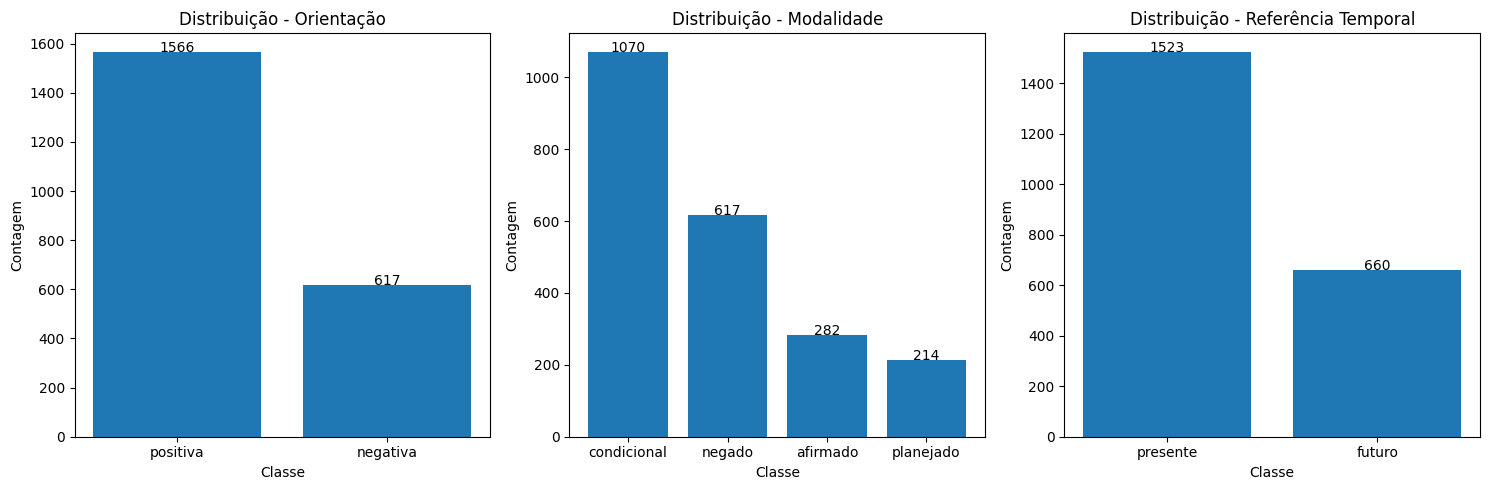

In [108]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Orientação
orientacao_counts = pd.Series(ds_enc['orientacao_label']).value_counts()
axes[0].bar(orientacao_counts.index, orientacao_counts.values)
axes[0].set_title('Distribuição - Orientação')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Contagem')
for i, v in enumerate(orientacao_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center')

# Modalidade  
modalidade_counts = pd.Series(ds_enc['modalidade_label']).value_counts()
axes[1].bar(modalidade_counts.index, modalidade_counts.values)
axes[1].set_title('Distribuição - Modalidade')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Contagem')
for i, v in enumerate(modalidade_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center')

# Referência Temporal
temporal_counts = pd.Series(ds_enc['referencia_temporal_label']).value_counts()
axes[2].bar(temporal_counts.index, temporal_counts.values)
axes[2].set_title('Distribuição - Referência Temporal')
axes[2].set_xlabel('Classe')
axes[2].set_ylabel('Contagem')
for i, v in enumerate(temporal_counts.values):
    axes[2].text(i, v + 0.5, str(v), ha='center')

plt.tight_layout()
plt.show()


In [109]:
def calculate_class_weights(y_array):
    weights_dict = {}
    
    for i, label_name in enumerate(['referencia_temporal', 'modalidade', 'orientacao']):
        classes = np.unique(y_array[:, i])
        weights = compute_class_weight(
            class_weight='balanced',
            classes=classes,
            y=y_array[:, i]
        )
        weights_dict[label_name] = dict(zip(classes, weights))
        
        unique, counts = np.unique(y_array[:, i], return_counts=True)
        print(f"\n{label_name}:")
        for cls, count, weight in zip(unique, counts, weights):
            print(f"  Classe {cls}: {count:3} amostras → peso {weight:.3f}")
    
    return weights_dict


In [110]:
class_weights = calculate_class_weights(y_array)
class_weights



referencia_temporal:
  Classe 0: 660 amostras → peso 1.654
  Classe 1: 1523 amostras → peso 0.717

modalidade:
  Classe 0: 282 amostras → peso 1.935
  Classe 1: 1070 amostras → peso 0.510
  Classe 2: 617 amostras → peso 0.885
  Classe 3: 214 amostras → peso 2.550

orientacao:
  Classe 0: 617 amostras → peso 1.769
  Classe 1: 1566 amostras → peso 0.697


{'referencia_temporal': {0: 1.6537878787878788, 1: 0.716677609980302},
 'modalidade': {0: 1.9352836879432624,
  1: 0.5100467289719626,
  2: 0.8845218800648298,
  3: 2.550233644859813},
 'orientacao': {0: 1.7690437601296596, 1: 0.6969987228607918}}

In [111]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y_array, test_size=0.2, random_state=42, #stratify=y_array balancear mais antes de usar
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((1746, 145), (437, 145), (1746, 3), (437, 3))

In [112]:

classifiers = {
    'referencia_temporal': LogisticRegression(
        max_iter=1000,
        C=0.01,
        class_weight=class_weights['referencia_temporal']
    ),
    'modalidade': LogisticRegression(
        max_iter=1000,
        C=0.01,
        class_weight=class_weights['modalidade'] 
    ),
    'orientacao': LogisticRegression(
        max_iter=1000,
        C=0.01,
        class_weight=class_weights['orientacao']
    )
}

predictions = {}
for i, (task_name, clf) in enumerate(classifiers.items()):
    print(f"Treinando {task_name}...")
    clf.fit(X_train, y_train[:, i])
    predictions[task_name] = clf.predict(X_test)


print("\nBASELINE - Logistic Regression COM CLASS WEIGHTS:")
for i, task_name in enumerate(['referencia_temporal', 'modalidade', 'orientacao']):
    print(f"\n{task_name.upper()}:")
    print(classification_report(y_test[:, i], predictions[task_name]))


Treinando referencia_temporal...
Treinando modalidade...
Treinando orientacao...

BASELINE - Logistic Regression COM CLASS WEIGHTS:

REFERENCIA_TEMPORAL:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       112
           1       0.96      0.92      0.94       325

    accuracy                           0.92       437
   macro avg       0.88      0.91      0.89       437
weighted avg       0.92      0.92      0.92       437


MODALIDADE:
              precision    recall  f1-score   support

           0       0.87      0.98      0.93        63
           1       0.96      0.90      0.93       207
           2       0.98      0.94      0.96       125
           3       0.77      0.95      0.85        42

    accuracy                           0.93       437
   macro avg       0.90      0.94      0.92       437
weighted avg       0.94      0.93      0.93       437


ORIENTACAO:
              precision    recall  f1-score   support

   

In [113]:
for task_name, clf in classifiers.items():
    task_idx = ['referencia_temporal', 'modalidade', 'orientacao'].index(task_name)
    
    cv_scores = cross_val_score(
        clf, X_reduced, y_array[:, task_idx], 
        cv=5, scoring='f1_macro'
    )
    
    print(f"\n{task_name.upper()}:")
    print(f"  CV F1-macro: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")



REFERENCIA_TEMPORAL:
  CV F1-macro: 0.901 ± 0.019

MODALIDADE:
  CV F1-macro: 0.914 ± 0.012

ORIENTACAO:
  CV F1-macro: 0.966 ± 0.006


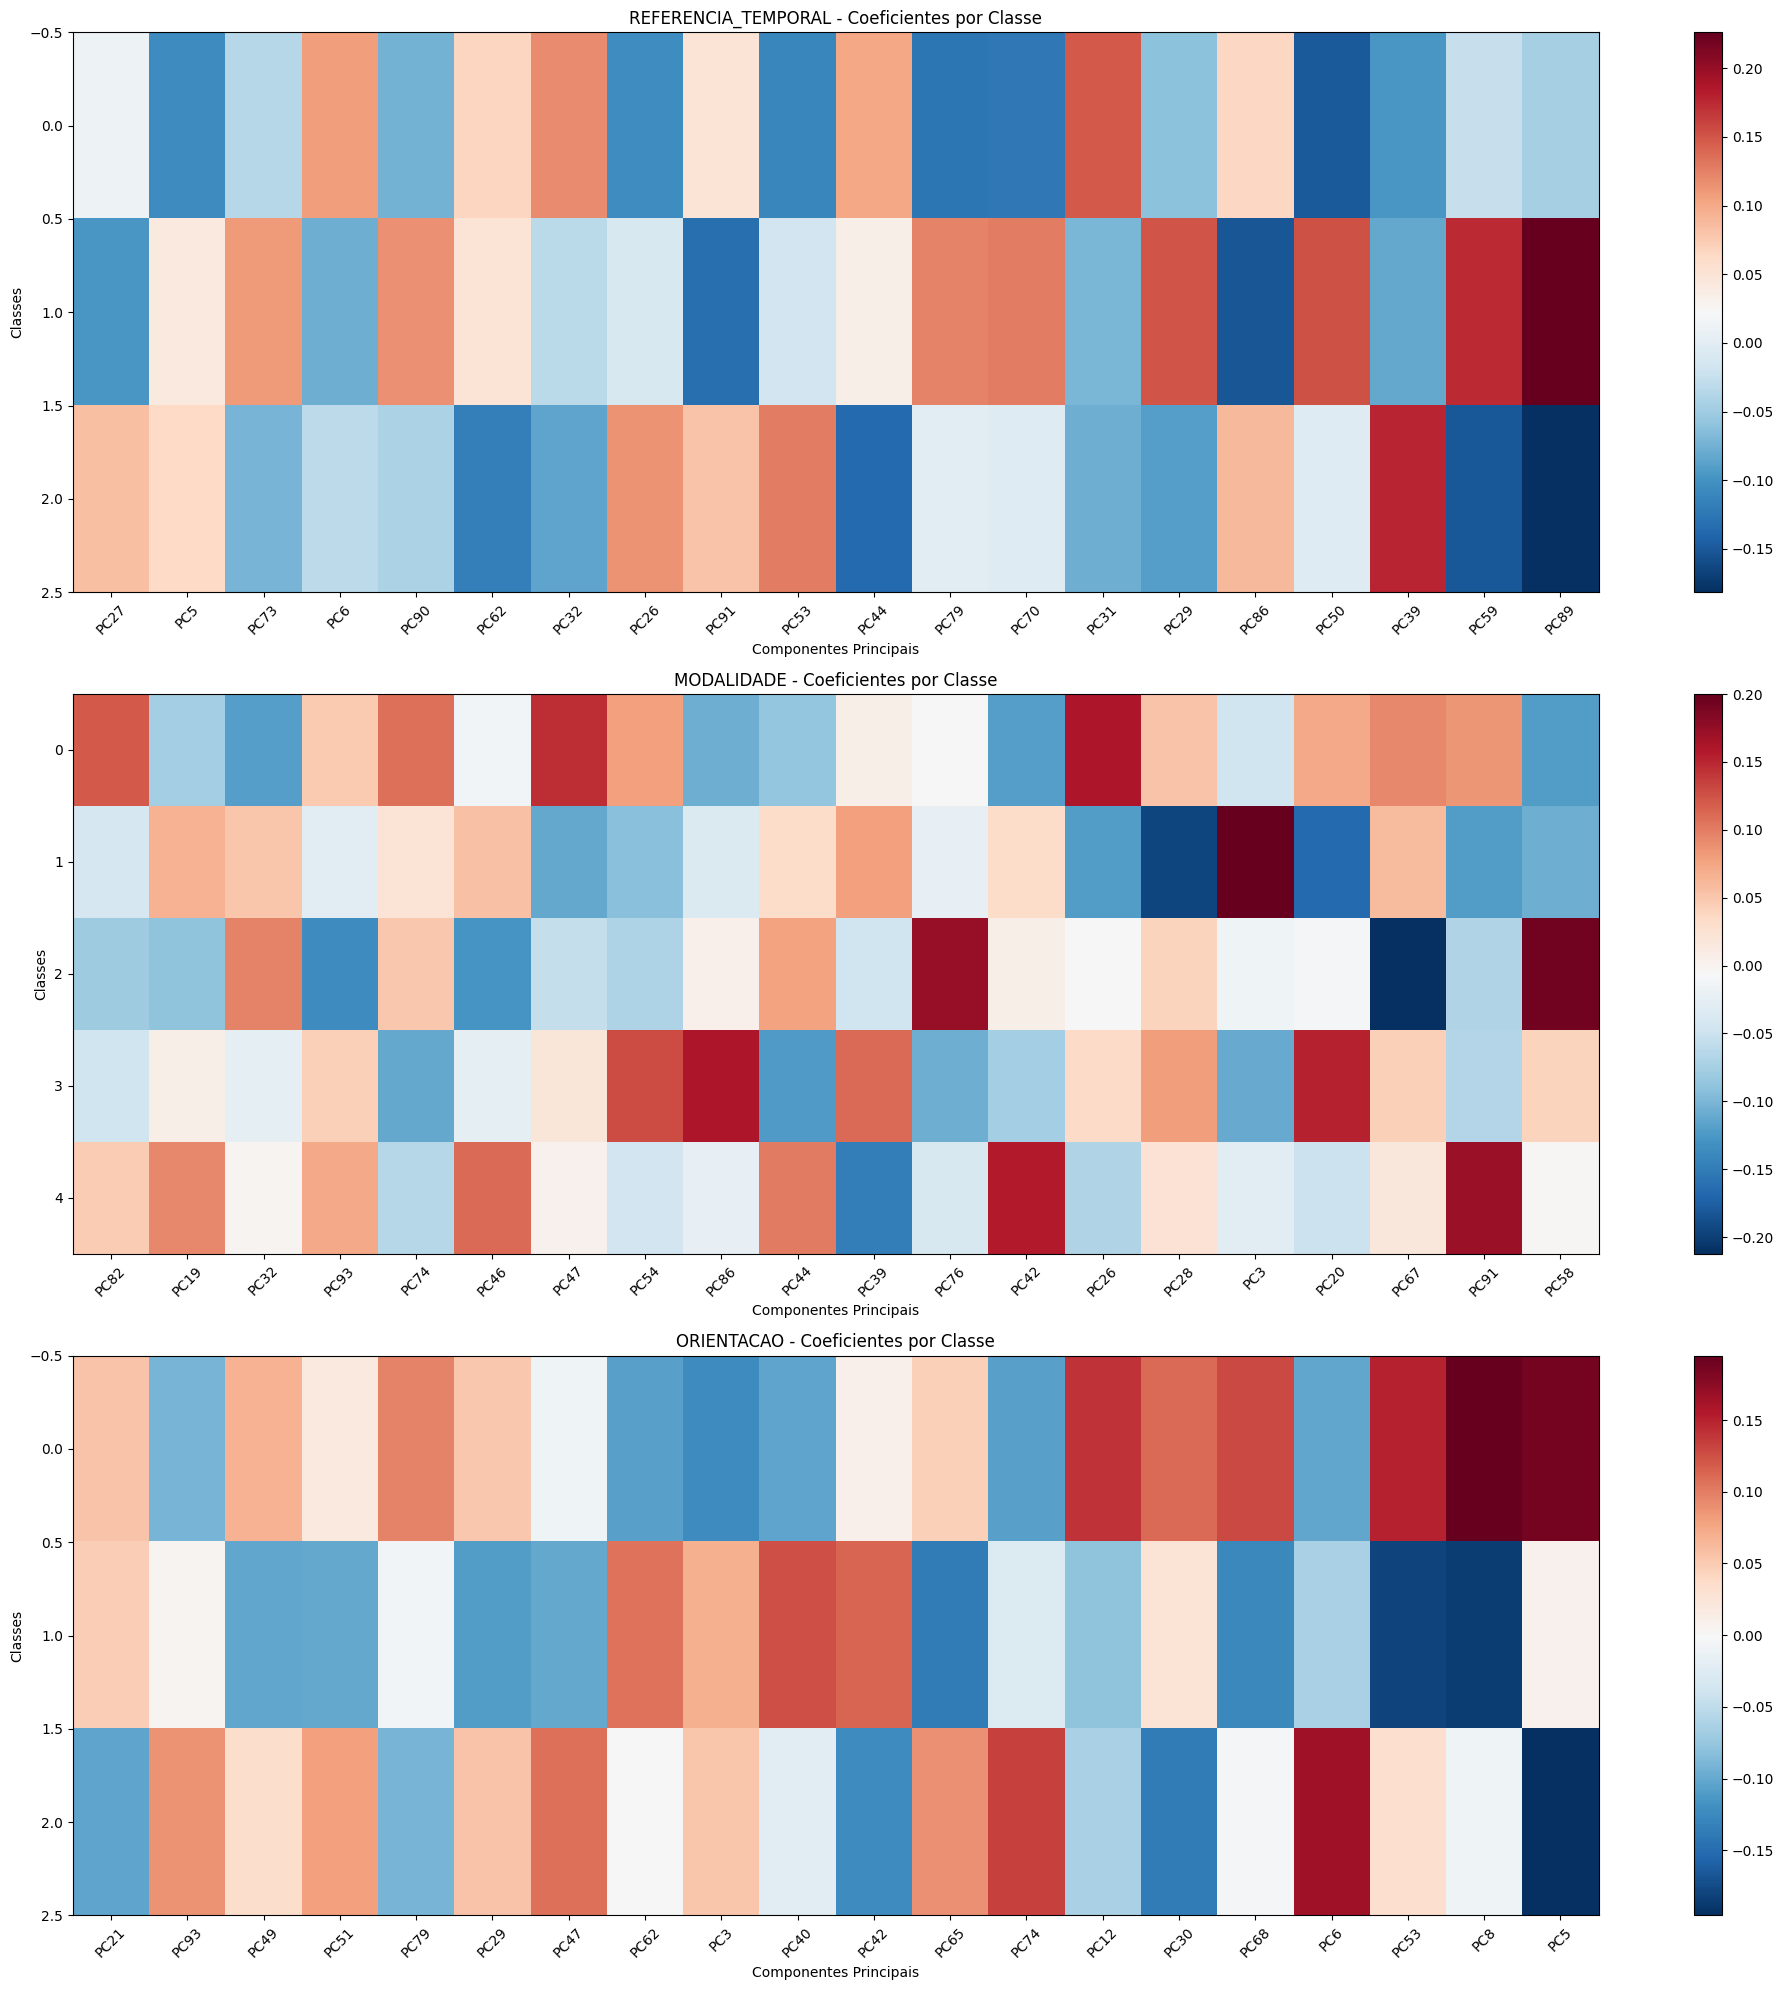

In [192]:
fig, axes = plt.subplots(3, 1, figsize=(20, 20))

for i, (task_name, clf) in enumerate(classifiers.items()):
    feature_importance = np.std(clf.coef_, axis=0) 
    top_indices = np.argsort(feature_importance)[-20:] 

    coef_subset = clf.coef_[:, top_indices]
    im = axes[i].imshow(coef_subset, cmap='RdBu_r', aspect='auto')
    
    axes[i].set_title(f'{task_name.upper()} - Coeficientes por Classe')
    axes[i].set_ylabel('Classes')
    axes[i].set_xlabel('Componentes Principais')
    axes[i].set_xticks(range(20))
    axes[i].set_xticklabels([f'PC{idx+1}' for idx in top_indices], rotation=45)
    
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.show()


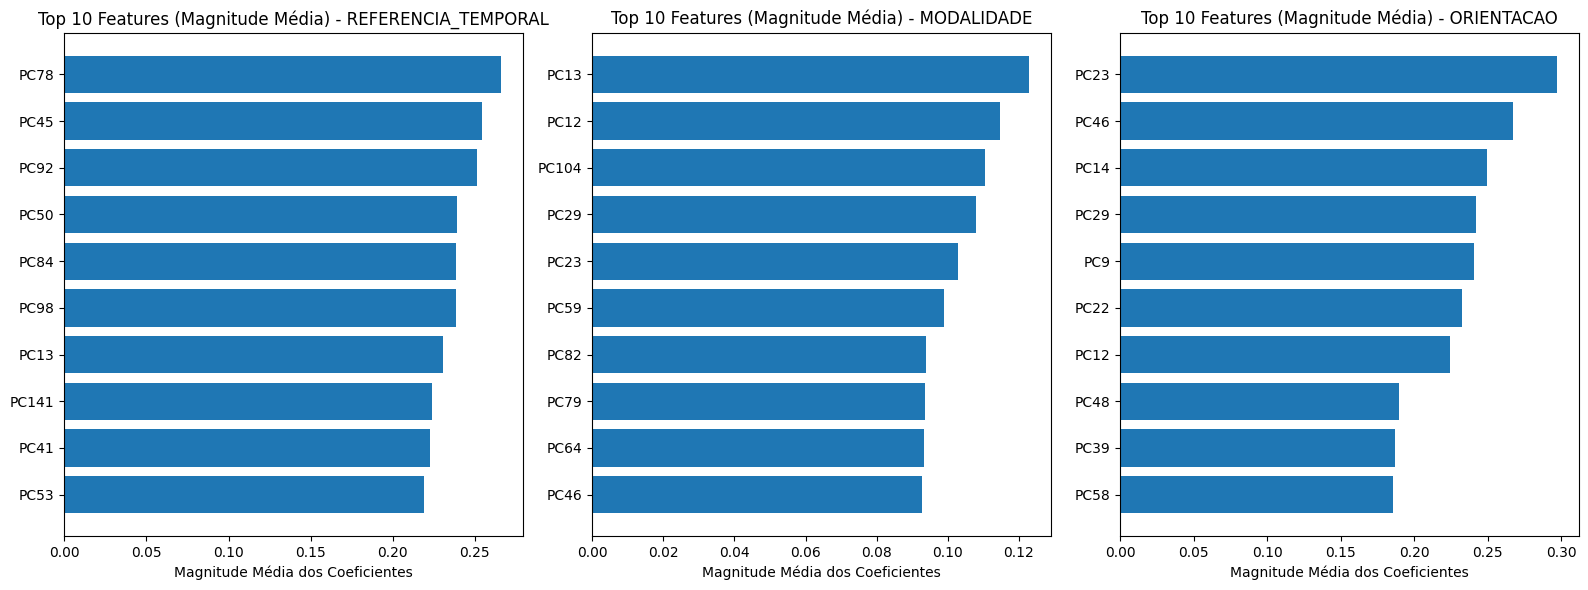

In [114]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, (task_name, clf) in enumerate(classifiers.items()):
    # Média da magnitude dos coeficientes entre todas as classes
    coefs_mean = np.mean(np.abs(clf.coef_), axis=0)
    top_indices = np.argsort(coefs_mean)[-10:]
    
    axes[i].barh(range(10), coefs_mean[top_indices])
    axes[i].set_title(f'Top 10 Features (Magnitude Média) - {task_name.upper()}')
    axes[i].set_xlabel('Magnitude Média dos Coeficientes')
    axes[i].set_yticks(range(10))
    axes[i].set_yticklabels([f'PC{idx+1}' for idx in top_indices])

plt.tight_layout()
plt.show()


In [115]:
def entity_type_to_onehot(entity_type, ohe_encoder):
    try:
        onehot = ohe_encoder.transform([[entity_type]])[0].tolist()
        return onehot
    except:
        return [0.0] * len(ohe_encoder.categories_[0])


In [116]:
def predictions_to_labels(predictions, encoders):
    return {
        'referencia_temporal': encoders['referencia_temporal_label'].inverse_transform([predictions['referencia_temporal']])[0],
        'modalidade': encoders['modalidade_label'].inverse_transform([predictions['modalidade']])[0], 
        'orientacao': encoders['orientacao_label'].inverse_transform([predictions['orientacao']])[0]
    }


In [117]:
def pipeline_inf(frase, ner_model, ner_tokenizer, classifiers, pca, scaler, ohe_encoder, label_encoders):
    ner = pipeline("token-classification", model=ner_model, tokenizer=ner_tokenizer, aggregation_strategy="simple")
    entidades = ner(frase)
    
    resultados = []
    
    for ent in entidades:
        examples_batch = {
            "text": [frase], 
            "start": [ent['start']], 
            "end": [ent['end']] 
        }
        
        dados_encoded = encode_and_extract_spans(examples_batch)
        features = extract_entity_features(
            ner_model.bert,
            dados_encoded['input_ids'][0],
            dados_encoded['attention_mask'][0],
            dados_encoded['span_token_indices'][0],
            entity_type_to_onehot(ent['entity_group'], ohe_encoder)
        )
        
        features_scaled = scaler.transform([features.cpu().numpy()])
        features_reduced = pca.transform(features_scaled)
        
        predictions = {}
        scores = {}
        for task_name, clf in classifiers.items():
            predictions[task_name] = clf.predict(features_reduced)[0]
            scores[task_name] = clf.predict_proba(features_reduced)[0]

        labels = predictions_to_labels(predictions, label_encoders)
        
        resultado = {
            'texto': ent['word'],
            'entidade': ent['entity_group'],
            'referencia_temporal': labels['referencia_temporal'],
            'modalidade': labels['modalidade'], 
            'orientacao': labels['orientacao'],
            'score_ner': ent['score'],
            'score': scores
        }
        resultados.append(resultado)
    return resultados 


In [118]:
frases = ["600 ta muito caro", "Nao consigo pagar esse mes, so mes que vem", "podemos fazer em 3x de 50?", "nao consigo, perdi o emprego"]

for frase in frases:
    resultados = pipeline_inf(frase, model, tokenizer, classifiers, pca, scaler, ohe, encoders) 
    print("RESULTADOS:")
    print("-" * 70)
    for i, res in enumerate(resultados, 1):
        print(f"{i}. {'**' + res['texto'] + '**':30} -> {res['entidade']:16} (score: {res['score_ner']:.2f})")
        print(f"   Referencia Temporal {'':10} -> {res['referencia_temporal'].upper():16} (score: {max(res['score']['referencia_temporal']):.2f})")
        print(f"   Modalidade {'':19} -> {res['modalidade'].upper():16} (score: {max(res['score']['modalidade']):.2f})")
        print(f"   Orientacao {'':19} -> {res['orientacao'].upper():16} (score: {max(res['score']['orientacao']):.2f})")
        print()
        

Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0


RESULTADOS:
----------------------------------------------------------------------
1. **600**                        -> VALOR            (score: 0.93)
   Referencia Temporal            -> PRESENTE         (score: 1.00)
   Modalidade                     -> NEGADO           (score: 0.92)
   Orientacao                     -> NEGATIVA         (score: 0.86)

2. **muito caro**                 -> VALOR            (score: 0.92)
   Referencia Temporal            -> PRESENTE         (score: 1.00)
   Modalidade                     -> NEGADO           (score: 0.75)
   Orientacao                     -> NEGATIVA         (score: 0.71)

RESULTADOS:
----------------------------------------------------------------------
1. **Nao consigo**                -> CONDICAO         (score: 0.52)
   Referencia Temporal            -> PRESENTE         (score: 0.86)
   Modalidade                     -> NEGADO           (score: 0.90)
   Orientacao                     -> NEGATIVA         (score: 0.81)

2. **pagar**   

Device set to use cuda:0


RESULTADOS:
----------------------------------------------------------------------
1. **nao consigo, perdi o emprego** -> CONDICAO         (score: 0.82)
   Referencia Temporal            -> PRESENTE         (score: 0.88)
   Modalidade                     -> NEGADO           (score: 0.99)
   Orientacao                     -> NEGATIVA         (score: 0.99)



In [119]:
for task_name, clf in classifiers.items():
    # Pegar algumas amostras de treino
    sample_features = X_reduced[:10]
    probabilities = clf.predict_proba(sample_features)
    
    print(f"\n{task_name}:")
    print(f"  Min probability: {probabilities.min():.6f}")
    print(f"  Max probability: {probabilities.max():.6f}")
    print(f"  Samples with prob > 0.99: {(probabilities.max(axis=1) > 0.99).sum()}/10")
    print(f"  Samples with prob > 0.999: {(probabilities.max(axis=1) > 0.999).sum()}/10")
    
    # Mostrar algumas probabilidades
    print(f"  First 3 max probabilities: {probabilities.max(axis=1)[:3]}")



referencia_temporal:
  Min probability: 0.001215
  Max probability: 0.998785
  Samples with prob > 0.99: 2/10
  Samples with prob > 0.999: 0/10
  First 3 max probabilities: [0.95944308 0.68385557 0.5989218 ]

modalidade:
  Min probability: 0.000001
  Max probability: 0.979625
  Samples with prob > 0.99: 0/10
  Samples with prob > 0.999: 0/10
  First 3 max probabilities: [0.91020338 0.79679394 0.91583813]

orientacao:
  Min probability: 0.000295
  Max probability: 0.999705
  Samples with prob > 0.99: 5/10
  Samples with prob > 0.999: 1/10
  First 3 max probabilities: [0.93375893 0.99970506 0.99446469]


In [132]:
def gerar_relatorio(frase, entidades):
    """Versão corrigida do gerador de relatório"""
    relatorio = f"Frase: \"{frase}\"\n"

    for ent in entidades:
        texto = ent['texto']
        ent_label = ent['entidade']
        tempo = ent.get('referencia_temporal', '')
        modalidade = ent.get('modalidade', '')
        orientacao = ent.get('orientacao', '')

        # Descrição do tempo quando ausente
        if tempo == 'presente':
            tempo_desc = "agora"
        elif tempo == 'futuro':
            tempo_desc = "no futuro"
        elif tempo == 'passado':
            tempo_desc = "no passado"
        else:
            tempo_desc = ""

        # Mapeamento da orientação
        if orientacao == 'negativa':
            pode = "não pode"
        elif orientacao == 'positiva':
            pode = "pode"
        elif orientacao == 'neutra':
            pode = "poderia"
        else:
            pode = ""

        if ent_label == 'PAGAMENTO':
            if modalidade == 'afirmado':
                relatorio += f"A pessoa afirma que {pode} pagar {tempo_desc}.\n"
            elif modalidade == 'negado':
                relatorio += f"A pessoa diz que {pode} pagar {tempo_desc}.\n"
            elif modalidade == 'condicional':
                relatorio += f"A pessoa diz que {pode} pagar dada a condição.\n"
            elif modalidade == 'incerto':
                relatorio += f"A pessoa diz que {pode} pagar, mas expressa incerteza sobre o ato.\n"
            elif modalidade == 'planejado':
                relatorio += f"A pessoa diz que {pode} pagar, mas isso está planejado para algum momento futuro.\n"

        elif ent_label == 'VALOR':
            if modalidade == 'afirmado':
                relatorio += f"A pessoa afirma que {pode} pagar o valor \"{texto}\" {tempo_desc}.\n"
            elif modalidade == 'negado':
                relatorio += f"A pessoa afirma que {pode} pagar o valor \"{texto}\" {tempo_desc}.\n"
            elif modalidade == 'condicional':
                relatorio += f"A pessoa coloca como condição o valor \"{texto}\" para pagar {tempo_desc}.\n"
            elif modalidade == 'incerto':
                relatorio += f"A pessoa diz que {pode} pagar o valor \"{texto}\", mas expressa incerteza.\n"
            elif modalidade == 'planejado':
                relatorio += f"A pessoa planeja pagar o valor \"{texto}\" no futuro {tempo_desc}.\n"
            else:
                relatorio += f"A pessoa {pode} pagar o valor \"{texto}\" {tempo_desc}.\n"

        elif ent_label == 'TEMPO':
            if modalidade == 'afirmado':
                relatorio += f"A pessoa afirma que {pode} pagar em \"{texto}\", mencionado como \"{texto}\".\n"
            elif modalidade == 'negado':
                relatorio += f"A pessoa afirma que {pode} pagar em \"{texto}\", mencionado como \"{texto}\".\n"
            elif modalidade == 'condicional':
                relatorio += f"A pessoa menciona que {pode} pagar em \"{texto}\" dada a condição.\n"
            elif modalidade == 'incerto':
                relatorio += f"A pessoa diz que {pode} pagar em \"{texto}\", mas está incerta.\n"
            elif modalidade == 'planejado':
                relatorio += f"A pessoa planeja pagar em \"{texto}\" no futuro.\n"
            else:
                relatorio += f"A pessoa {pode} pagar {tempo_desc}, mencionado como \"{texto}\".\n"

        elif ent_label == 'CONDICAO':
            if modalidade == 'afirmado':
                relatorio += f"A pessoa afirma que {pode} pagar sob a condição \"{texto}\".\n"
            elif modalidade == 'negado':
                relatorio += f"A pessoa afirma que {pode} pagar mesmo sob a condição \"{texto}\".\n"
            elif modalidade == 'condicional':
                relatorio += f"A pessoa define a condição \"{texto}\" como {"requisito" if orientacao == 'positiva' else "impeditivo"} para pagar.\n"
            elif modalidade == 'incerto':
                relatorio += f"A pessoa expressa incerteza sobre pagar, mencionando a condição \"{texto}\".\n"
            elif modalidade == 'planejado':
                relatorio += f"A pessoa planeja pagar desde que a condição \"{texto}\" seja atendida no futuro.\n"
            else:
                relatorio += f"A pessoa {pode} pagar sob a condição \"{texto}\".\n"

    return relatorio


In [133]:
resultados = {}
for frase in ["posso pagar 780?", "semana que vem prometo pagar", "nao consigo, perdi o emprego","quero quitar essa divida", "vamos fazer 3x sem juros", "nao consigo pagar esse mes, so mes que vem"]:
    resultados[frase] = pipeline_inf(frase, model, tokenizer, classifiers, pca, scaler, ohe, encoders)



Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0


In [134]:

for frase in resultados.keys():
    print(f'{60*'-'}')
    print(gerar_relatorio(frase, resultados[frase]))
    


------------------------------------------------------------
Frase: "posso pagar 780?"
A pessoa afirma que pode pagar agora.
A pessoa coloca como condição o valor "780?" para pagar agora.

------------------------------------------------------------
Frase: "semana que vem prometo pagar"
A pessoa afirma que pode pagar em "semana que vem", mencionado como "semana que vem".
A pessoa afirma que pode pagar no futuro.
A pessoa afirma que pode pagar no futuro.

------------------------------------------------------------
Frase: "nao consigo, perdi o emprego"
A pessoa afirma que não pode pagar mesmo sob a condição "nao consigo, perdi o emprego".

------------------------------------------------------------
Frase: "quero quitar essa divida"
A pessoa diz que não pode pagar agora.
A pessoa afirma que pode pagar mesmo sob a condição "divida".

------------------------------------------------------------
Frase: "vamos fazer 3x sem juros"
A pessoa define a condição "3x" como requisito para pagar.
A 

In [137]:

pipeline_components_dill = {
    'model': model,
    'tokenizer': tokenizer, 
    'classifiers': classifiers,
    'pca': pca,
    'scaler': scaler,
    'ohe_encoder': ohe,
    'label_encoders': encoders,
    'pipeline_function': pipeline_inf,
    'helper_functions': {
        'entity_type_to_onehot': entity_type_to_onehot,
        'predictions_to_labels': predictions_to_labels,
        'encode_and_extract_spans': encode_and_extract_spans,
        'extract_entity_features': extract_entity_features,
        'gerar_relatorio': gerar_relatorio
    }
}

with open('../model/ner_bert_dill.pkl', 'wb') as f:
    dill.dump(pipeline_components_dill, f)

print(f"Tamanho do arquivo: {os.path.getsize('../model/ner_bert_dill.pkl') / (1024*1024):.2f} MB")



Tamanho do arquivo: 416.45 MB
